In [1]:
import pickle
import torch
import evaluate
import os
import csv

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
from huggingface_hub import login
from transformers import AutoImageProcessor, ViTForImageClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from dotenv import load_dotenv

In [ ]:
### Login for Hugging Face model
load_dotenv()
login(token=os.environ["HF_TOKEN"])

### Setam seedul pt random
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Variabile globale
MODEL_NAME = "google/vit-large-patch16-224"
IMAGE_SIZE = 224
EVAL_RESIZE = 256 

### VIT processor + move device to cuda
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast = True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Augmentar inspirata din cum augumenteaza lucrarea datele pentru CUB
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
])

eval_transform = transforms.Compose([
    transforms.Resize(EVAL_RESIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
])

### Dataset pentru x -> y
class ImageDataset(Dataset):
    def __init__(self, images_paths, labels, aug = None):
        self.images_paths = images_paths
        self.labels = labels
        self.aug = aug

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, i):
        img = Image.open(self.images_paths[i]).convert("RGB")
        
        if self.aug is not None:
            img = self.aug(img)
            
        inputs = image_processor(
            images=img, 
            return_tensors="pt", 
            do_resize=False,  
            do_center_crop=False 
        )
        pixel_values = inputs["pixel_values"].squeeze(0)
        return {"pixel_values": pixel_values, "labels": torch.tensor(self.labels[i])}

### Metricile pe care le va urmarii modelul

# Metrici x->y
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric   = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1":        f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"],
        "precision": precision_metric.compute(predictions=predictions, references=labels, average="macro")["precision"],
        "recall":    recall_metric.compute(predictions=predictions, references=labels, average="macro")["recall"],
    }


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
### Load images + labels parsing
with open("all_images.pkl", "rb") as f:
    imgs_path = pickle.load(f)
    
label_names = {name: i for i, name in enumerate(list(imgs_path.keys()))}
all_data = []
all_labels = []

for s in imgs_path:    
    for img_path in imgs_path[s]:
        all_data.append(img_path)
        all_labels.append(label_names[s])

print(len(all_data))
print(len(all_labels))

# 80% din date pentru tain si 20% pt test
aux_data, test_data, aux_labels, test_labels = train_test_split(
    all_data, all_labels, 
    test_size=0.20, 
    random_state=SEED, 
    stratify=all_labels
)

# Alegem 20% din datele de train pentru evaluare
train_data, eval_data, train_labels, eval_labels = train_test_split(
    aux_data, aux_labels, 
    test_size=0.20, 
    random_state=SEED,
    stratify=aux_labels
)

26107
26107


In [ ]:
run_idx = 1
while os.path.exists(f"./vit/run{run_idx}"):
    run_idx += 1
run_dir = f"./vit/run{run_idx}"
os.makedirs(run_dir, exist_ok=True)

checkpoint_dir = os.path.join(run_dir, "checkpoints")
model_dir = os.path.join(run_dir, "models")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

train_dataset = ImageDataset(train_data, train_labels, aug=train_transform)
eval_dataset = ImageDataset(eval_data, eval_labels, aug=eval_transform)
test_dataset = ImageDataset(test_data, test_labels, aug=eval_transform)

model = ViTForImageClassification.from_pretrained(
    "./vit/run1/models",
    num_labels=len(label_names),
    ignore_mismatched_sizes=True
)
model = model.to(device)

args = TrainingArguments(
    output_dir=checkpoint_dir,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    report_to="none",
    num_train_epochs=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [12]:
train_output = trainer.train()
trainer.save_model(model_dir)

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [7]:
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks 
    if cb.__class__.__name__ in ["ProgressCallback", "DefaultFlowCallback", "PrinterCallback"]
]

test_results = trainer.evaluate(test_dataset)

test_results_path = os.path.join(run_dir, "test_results.txt")
with open(test_results_path, "w") as f:
    f.write(f"Test Results:\n")
    f.write(f"Accuracy:  {test_results.get('eval_accuracy', '')}\n")
    f.write(f"F1:        {test_results.get('eval_f1', '')}\n")
    f.write(f"Precision: {test_results.get('eval_precision', '')}\n")
    f.write(f"Recall:    {test_results.get('eval_recall', '')}\n")
    f.write(f"Loss:      {test_results.get('eval_loss', '')}\n")

print(f"\nTest results saved to: {test_results_path}")

c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Text predictions (first 20):
000 | true: penholder | pred: penholder
001 | true: pheasant | pred: pheasant
002 | true: flypaper | pred: flypaper
003 | true: shrimp | pred: shrimp
004 | true: coffee_bean | pred: coffee_bean
005 | true: ham | pred: ham
006 | true: cashew | pred: cashew
007 | true: doorknocker | pred: doorknocker
008 | true: card | pred: card
009 | true: potpourri | pred: potpourri
010 | true: loom | pred: loom
011 | true: elbow | pred: elbow
012 | true: sequin | pred: sequin
013 | true: tube_top | pred: tube_top
014 | true: crab | pred: crab
015 | true: headband | pred: headband
016 | true: windshield | pred: windshield
017 | true: shears | pred: shears
018 | true: noisemaker | pred: noisemaker
019 | true: recorder | pred: recorder

Test results saved to: ./vit/run2\test_results.txt


c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
print(trainer.state.log_history)
eval_history = [entry for entry in trainer.state.log_history]
print(eval_history)

[{'loss': 7.669029541015625, 'grad_norm': 8.307199478149414, 'learning_rate': 1.875598086124402e-07, 'epoch': 0.04784688995215311, 'step': 50}, {'loss': 7.650504150390625, 'grad_norm': 7.759328842163086, 'learning_rate': 3.789473684210527e-07, 'epoch': 0.09569377990430622, 'step': 100}, {'loss': 7.67373779296875, 'grad_norm': 8.373373985290527, 'learning_rate': 5.703349282296651e-07, 'epoch': 0.14354066985645933, 'step': 150}, {'loss': 7.653079833984375, 'grad_norm': 16.02816390991211, 'learning_rate': 7.617224880382776e-07, 'epoch': 0.19138755980861244, 'step': 200}, {'loss': 7.666856079101563, 'grad_norm': 7.962357997894287, 'learning_rate': 9.531100478468901e-07, 'epoch': 0.23923444976076555, 'step': 250}, {'loss': 7.625559692382812, 'grad_norm': 9.52790355682373, 'learning_rate': 1.1444976076555026e-06, 'epoch': 0.28708133971291866, 'step': 300}, {'loss': 7.639529418945313, 'grad_norm': 8.316397666931152, 'learning_rate': 1.3358851674641148e-06, 'epoch': 0.3349282296650718, 'step':

In [17]:
eval_history = [entry for entry in trainer.state.log_history if "eval_loss" in entry]

data = {
    "epoch": [],
    "loss": [],
    "accuracy": [],
    "f1": [],
    "precision": [],
    "recall": [],
}

csv_path = os.path.join(checkpoint_dir, "result.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "loss", "accuracy", "f1", "precision", "recall"])
    writer.writeheader()
    for entry in eval_history:
        writer.writerow({
            "epoch": entry.get("epoch", ""),
            "loss": entry.get("eval_loss", ""),
            "accuracy": entry.get("eval_accuracy", ""),
            "f1": entry.get("eval_f1", ""),
            "precision": entry.get("eval_precision", ""),
            "recall": entry.get("eval_recall", ""),
        })

with open(csv_path, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        data["epoch"].append(float(row["epoch"]))
        data["loss"].append(float(row["loss"]))
        data["accuracy"].append(float(row["accuracy"]))
        data["f1"].append(float(row["f1"]))
        data["precision"].append(float(row["precision"]))
        data["recall"].append(float(row["recall"]))

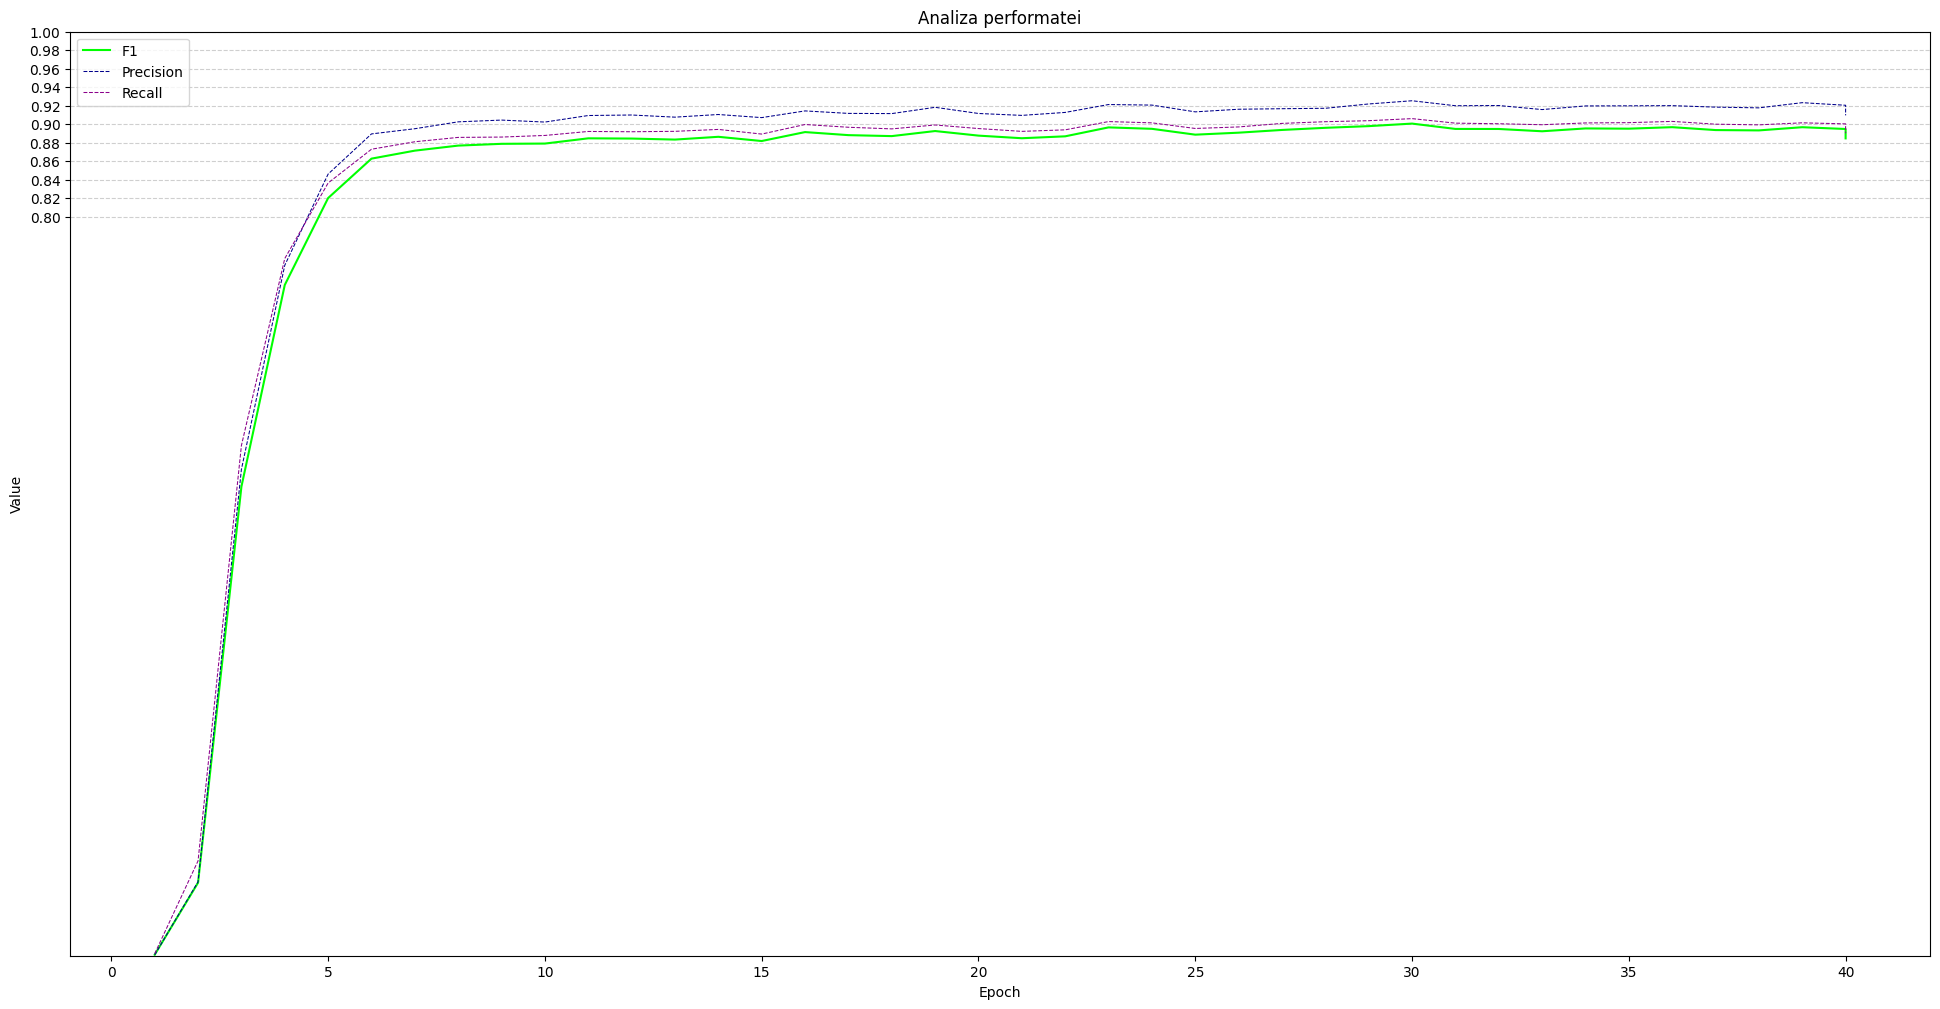

In [18]:
plt.figure(figsize=(24, 12))
plt.plot(data["epoch"], data["f1"], linewidth = 1.5, c = 'lime', label = 'F1')
plt.plot(data["epoch"], data["precision"], linewidth = 0.75, c ='darkblue', ls = "--", label = 'Precision')
plt.plot(data["epoch"], data["recall"], linewidth = 0.75, c = 'darkmagenta', ls = "--", label = 'Recall')

plt.ylim(0, 1.0)
plt.yticks(np.arange(0.8, 1.01, 0.02))
plt.title('Analiza performatei')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig(os.path.join(os.path.dirname(csv_path), "performance.pdf"))
plt.show()